# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Dataset 

In [3]:
df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv", delimiter=',')
# pandas operations
print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
df.isnull().sum()

#Numpy operations
# Convert columns to numpy arrays
year_arr = df['Year'].values
revenue_arr = df['Revenue_USD'].values
roi_arr = df['AI_ROI_Percent'].values
maturity_arr = df['AI_Maturity_Score'].values

# Year statistics
print("\n--- YEAR STATISTICS ---")
print(f"Mean: {np.mean(year_arr):.2f}")
print(f"Median: {np.median(year_arr):.2f}")
print(f"Std: {np.std(year_arr):.2f}")
print(f"Min: {np.min(year_arr)}")
print(f"Max: {np.max(year_arr)}")
print(f"Range: {np.max(year_arr) - np.min(year_arr)}")


df:        Year             Company    Industry Country Company_Type Employee_Size  \
0     2020              Amazon  E-commerce     USA         Real    Enterprise   
1     2021              Amazon  E-commerce     USA         Real    Enterprise   
2     2022              Amazon  E-commerce     USA         Real    Enterprise   
3     2023              Amazon  E-commerce     USA         Real    Enterprise   
4     2024              Amazon  E-commerce     USA         Real    Enterprise   
...    ...                 ...         ...     ...          ...           ...   
5995  2021  SyntheticCorp_0980     Telecom  Brazil    Synthetic    Enterprise   
5996  2022  SyntheticCorp_0980     Finance   India    Synthetic           SME   
5997  2023  SyntheticCorp_0980  Technology  Canada    Synthetic    Enterprise   
5998  2024  SyntheticCorp_0980   Logistics     UAE    Synthetic    Enterprise   
5999  2025  SyntheticCorp_0980  Healthcare   Japan    Synthetic           SME   

       Revenue_USD Use

# Feature Selection

In [4]:
# No AI_ROI_Percent 
features = df[['Revenue_USD', 'AI_Maturity_Score', 'Year']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow Method

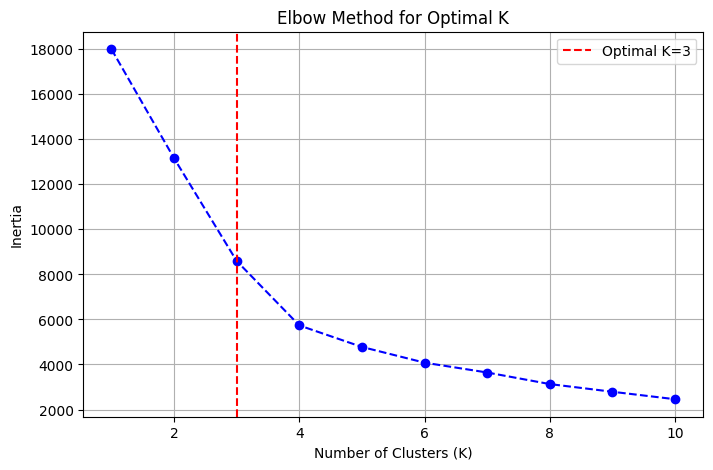

In [5]:
# Elbow Method with random_state
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)  # Added n_init
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Better elbow plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.axvline(x=3, color='r', linestyle='--', label='Optimal K=3')
plt.legend()
plt.show()

# Train K Means

In [ ]:

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Centers 

In [7]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features.columns)
print("Cluster Centers:\n", centers_df)

Cluster Centers:
     Revenue_USD  AI_Maturity_Score         Year
0  9.881995e+09          31.681468  2022.426824
1  1.118447e+10          67.453074  2022.542071
2  3.405299e+11          81.341176  2022.564706


# Dynamic labeling on the basis of maturity score

In [8]:
sorted_clusters = centers_df['AI_Maturity_Score'].rank().astype(int)
label_map = {
    sorted_clusters.idxmin(): "Low AI Adoption",
    sorted_clusters.median().astype(int): "Medium AI Adoption",
    sorted_clusters.idxmax(): "High AI Leaders"
}
df['Cluster_Label'] = df['Cluster'].map(label_map)

# Group Means

In [9]:
print("\nCluster Group Means:")
print(df.groupby('Cluster_Label')[['Revenue_USD', 'AI_Maturity_Score', 'Year']].mean())


Cluster Group Means:
                  Revenue_USD  AI_Maturity_Score         Year
Cluster_Label                                                
High AI Leaders  3.405299e+11          81.341176  2022.564706
Low AI Adoption  9.913677e+09          31.697601  2022.426437


# Plot Visualization

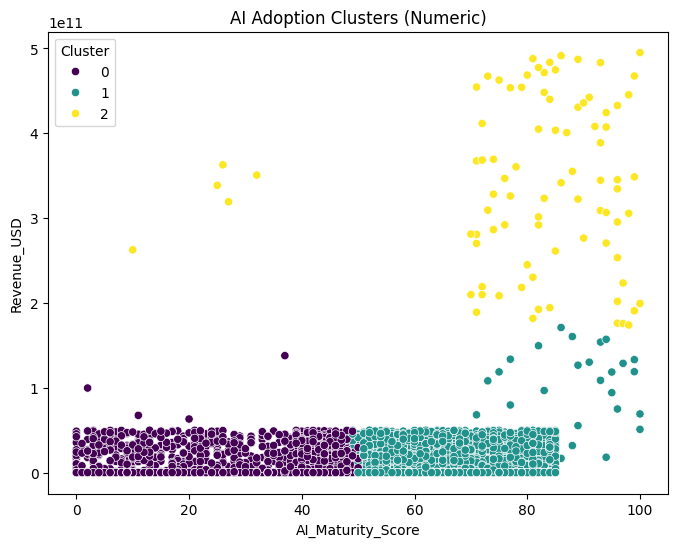

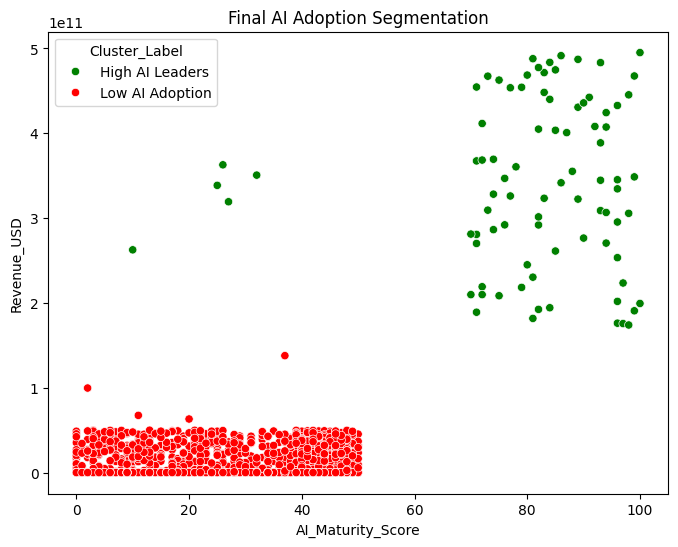

In [10]:
# Plot 1 — numeric clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='AI_Maturity_Score', y='Revenue_USD', hue='Cluster', data=df, palette='viridis')
plt.title("AI Adoption Clusters (Numeric)")
plt.show()

# Plot 2 — labeled clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='AI_Maturity_Score', y='Revenue_USD', hue='Cluster_Label', data=df,
                palette={'Low AI Adoption': 'red', 'Medium AI Adoption': 'orange', 'High AI Leaders': 'green'})
plt.title("Final AI Adoption Segmentation")
plt.show()

In [ ]:
# Applied KMeans clustering on Revenue_USD, AI_Maturity_Score,
# and Year using K=3 clusters.

# Cluster 0: Low AI Adoption
# Cluster 1: Medium AI Adoption
# Cluster 2: High AI Adoption

# KMeans successfully grouped companies into 3 segments
# without using any target labels.

# AI_Maturity_Score was the most important feature
# for differentiating  between clusters.

